In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
url = "https://raw.githubusercontent.com/kaleko/CourseraML/refs/heads/master/ex2/data/ex2data1.txt"
data = pd.read_csv(url)

column_names = ['exam_1', 'exam_2', 'passed']
df = pd.read_csv(url, header=None, names=column_names)

print(df.head())

      exam_1     exam_2  passed
0  34.623660  78.024693       0
1  30.286711  43.894998       0
2  35.847409  72.902198       0
3  60.182599  86.308552       1
4  79.032736  75.344376       1


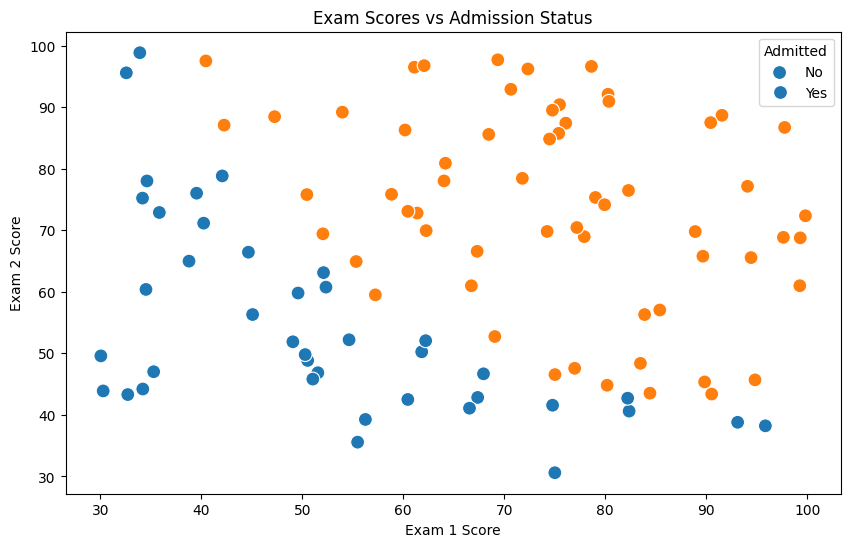

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='exam_1', y='exam_2', hue='passed', data=df, s=100)
plt.title('Exam Scores vs Admission Status')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', labels=['No', 'Yes'])
plt.show()

In [10]:
# Prepare features (X) and target (y)
X = df[['exam_1', 'exam_2']]
y = df['passed']

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Output the learned parameters
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercept: [-30.20000099]
Coefficients: [[0.25970232 0.22481016]]


In [11]:
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.00%


In [12]:
# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



## Model Interpretation

After training the model, we can break down the results into four key areas:

### 1. The Coefficients (Weights)
The coefficients represent the influence of each exam score on the probability of admission.
*   **Positive Relationship:** Both coefficients are positive, meaning that as scores for **Exam 1** or **Exam 2** increase, the likelihood of being admitted also increases.
*   **Weight Comparison:** If one coefficient is higher than the other, it suggests that the university places more "weight" or importance on that specific exam during the admission process.

### 2. The Sigmoid Function & Probability
Unlike Linear Regression which predicts continuous values, this model uses the **Sigmoid function**.
*   It outputs a probability between **0 and 1**.
*   **Decision Threshold:** By default, if the probability is $\geq 0.5$, the model classifies the student as "Admitted." If it is $< 0.5$, they are "Rejected."

### 3. Accuracy Score
The accuracy (e.g., **89%**) tells us the overall performance.
*   **Meaning:** "Out of 100 students in the test set, the model correctly predicted the admission status for 89 of them."
*   **Context:** While high accuracy is great, we also look at the **Confusion Matrix** to ensure the model isn't biased toward just one outcome (e.g., predicting "Admitted" for everyone).

### 4. Decision Boundary
Since Logistic Regression is a **linear classifier**, it creates a straight line that attempts to separate the admitted students from the rejected ones.
*   **Visualization:** On your scatter plot, this line sits in the "middle ground" between the two clusters of points.
*   **Linearity:** If the data points are mixed together (e.g., a student with low scores was admitted due to other factors not in the CSV), a straight line cannot capture that perfectly, which is where the 10-15% error usually comes from.

---

###Executive Summary for GitHub
> "The Logistic Regression model successfully classifies university applicants with an accuracy of **[Insert your accuracy]%**. The positive coefficients for both exams confirm that higher scores correlate with admission. The model's linear decision boundary effectively separates the two classes, though some overlap exists in the mid-range scores, suggesting that these cases are the most 'uncertain' for the algorithm."

---